Computing spectral radius ...



MSE (first 500 steps, free-running) = 3.4156e-07


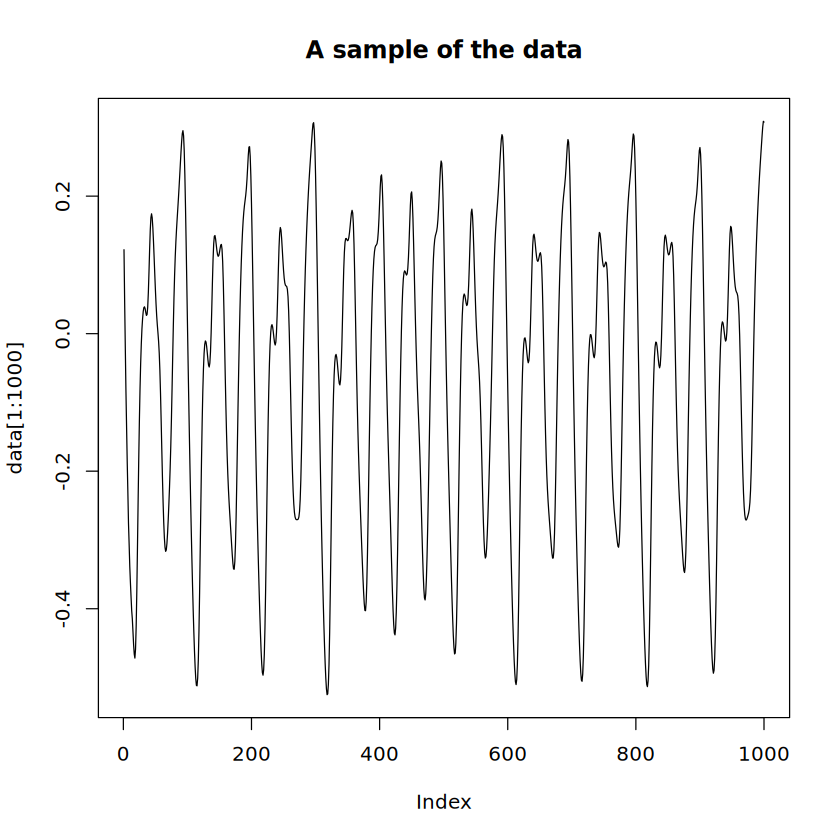

MSE (teacher-forcing, full test) = 3.72331e-08


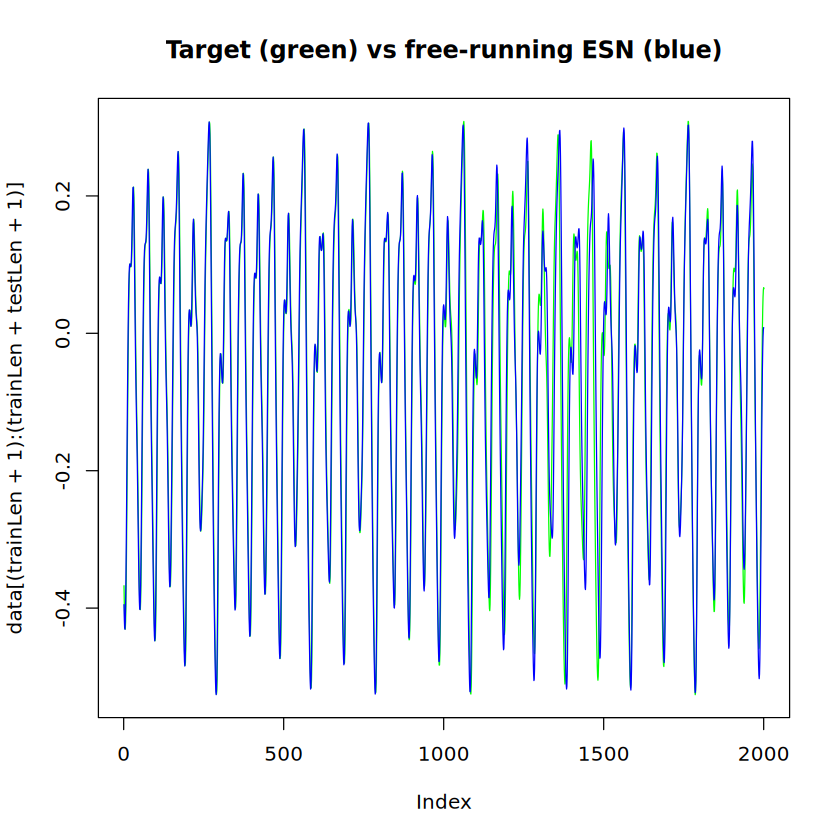

In [1]:
# Minimal ESN on Mackey–Glass (delay=17), Jupyter-friendly
# Source idea/code: M. Lukoševičius "minimalESN.r" and tutorial page

set.seed(42)

## -------------------------------
## 1) Data
## -------------------------------
trainLen <- 2000
testLen  <- 2000
initLen  <- 100

data <- as.matrix(
  read.table(
    url("https://mantas.info/wp/wp-content/uploads/simple_esn/MackeyGlass_t17.txt")
  )
)

# quick peek (optional)
plot(data[1:1000], type="l", main="A sample of the data")

## -------------------------------
## 2) Reservoir
## -------------------------------
inSize  <- 1
outSize <- 1
resSize <- 1000
a       <- 0.3  # leaking rate

Win <- matrix(runif(resSize * (1 + inSize), -0.5, 0.5), nrow = resSize)
W   <- matrix(runif(resSize * resSize,     -0.5, 0.5), nrow = resSize)

# Correct spectral radius scaling (use max eigenvalue magnitude)
message("Computing spectral radius ...")
rhoW <- max(Mod(eigen(W, only.values = TRUE)$values))
W    <- (1.25 / rhoW) * W

## -------------------------------
## 3) Collect reservoir states
## -------------------------------
X  <- matrix(0, nrow = 1 + inSize + resSize, ncol = trainLen - initLen)
Yt <- matrix(data[(initLen + 2):(trainLen + 1)], nrow = 1)

x <- rep(0, resSize)
for (t in 1:trainLen) {
  u <- data[t]
  x <- (1 - a) * x + a * tanh( Win %*% rbind(1, u) + W %*% x )
  if (t > initLen) X[, t - initLen] <- rbind(1, u, x)
}
x_state_after_train <- x  # remember final training state

## -------------------------------
## 4) Train readout (ridge)
## -------------------------------
reg  <- 1e-8
Xt   <- t(X)
Id   <- diag(nrow(X))  # (1 + inSize + resSize) x (1 + inSize + resSize)
Wout <- Yt %*% Xt %*% solve(X %*% Xt + reg * Id)

## -------------------------------
## 5) Free-running (generative) test
## -------------------------------
Y <- matrix(0, nrow = outSize, ncol = testLen)
x <- x_state_after_train
u <- data[trainLen + 1]

for (t in 1:testLen) {
  x <- (1 - a) * x + a * tanh( Win %*% rbind(1, u) + W %*% x )
  y <- Wout %*% rbind(1, u, x)
  Y[, t] <- y
  u <- y  # free-running
}

errorLen <- 500
mse_free <- mean( (data[(trainLen + 2):(trainLen + errorLen + 1)] - Y[1, 1:errorLen])^2 )
cat(sprintf("MSE (first %d steps, free-running) = %.6g\n", errorLen, mse_free))

# Plot: target vs free-running ESN
plot(data[(trainLen + 1):(trainLen + testLen + 1)], type="l", col="green",
     main="Target (green) vs free-running ESN (blue)")
lines(as.numeric(Y), col="blue")

## -------------------------------
## 6) Teacher-forcing (predictive) test (optional)
## -------------------------------
Ytf <- numeric(testLen)
x   <- x_state_after_train
u   <- data[trainLen + 1]

for (t in 1:testLen) {
  x     <- (1 - a) * x + a * tanh( Win %*% rbind(1, u) + W %*% x )
  y     <- Wout %*% rbind(1, u, x)
  Ytf[t] <- y
  u     <- data[trainLen + t + 1]  # teacher forcing
}

mse_tf <- mean( (data[(trainLen + 2):(trainLen + testLen + 1)] - Ytf)^2 )
cat(sprintf("MSE (teacher-forcing, full test) = %.6g\n", mse_tf))


ℹ Loading exdqlm


Static exAL LDVB | n=1900, p=301 | max_iter=1000, tol=1.0e-04
iter   50 | rel(mb)=1.81e-01 rel(xi)=1.41e+00 | gamma≈0.092 sigma≈0.001
    ELBO=3852.137037 | Δ=-2.554e+03 | Δrel=-3.99e-01
iter  100 | rel(mb)=1.92e-01 rel(xi)=4.76e-02 | gamma≈-0.151 sigma≈0.001
    ELBO=8063.253687 | Δ=6.836e+02 | Δrel=9.26e-02
iter  150 | rel(mb)=2.55e-01 rel(xi)=3.46e-01 | gamma≈-0.079 sigma≈0.001
    ELBO=8277.034005 | Δ=2.524e+02 | Δrel=3.15e-02
iter  200 | rel(mb)=2.07e-01 rel(xi)=5.15e-01 | gamma≈-0.045 sigma≈0.001
    ELBO=8042.281671 | Δ=-2.111e-01 | Δrel=-2.63e-05
iter  250 | rel(mb)=2.85e-02 rel(xi)=3.39e-01 | gamma≈-0.023 sigma≈0.001
    ELBO=8441.613785 | Δ=5.144e+02 | Δrel=6.49e-02
iter  300 | rel(mb)=2.93e-01 rel(xi)=3.66e-02 | gamma≈0.050 sigma≈0.001
    ELBO=6112.152340 | Δ=-2.116e+03 | Δrel=-2.57e-01
iter  350 | rel(mb)=1.41e-01 rel(xi)=9.78e-03 | gamma≈-0.273 sigma≈0.001
    ELBO=8239.296479 | Δ=1.109e+02 | Δrel=1.36e-02
iter  400 | rel(mb)=1.41e-01 rel(xi)=1.30e-02 | gamma≈-0.053 sigma

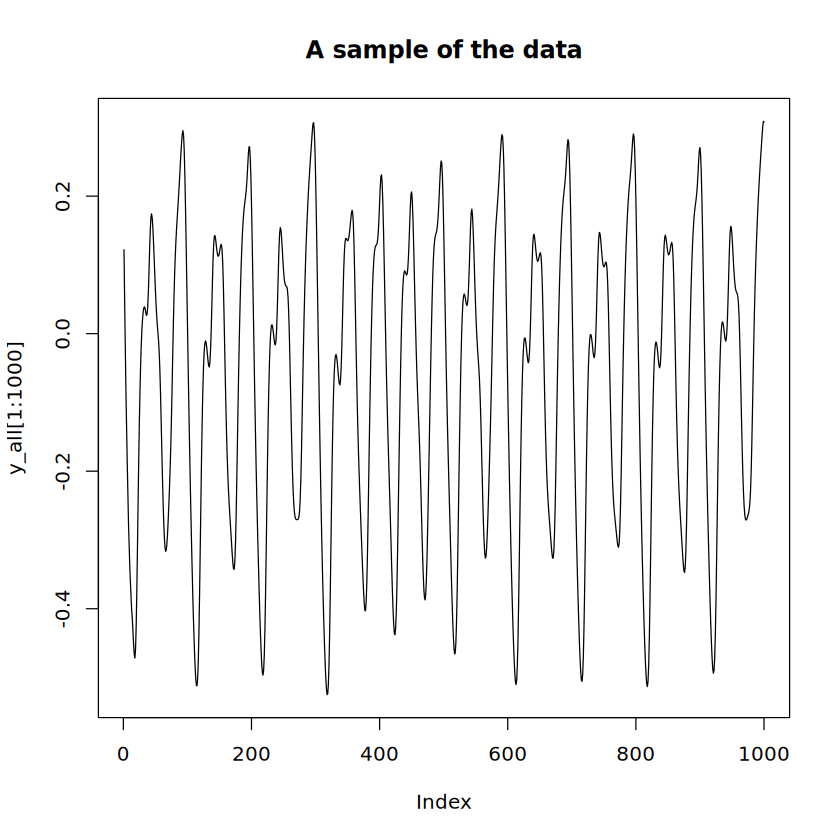

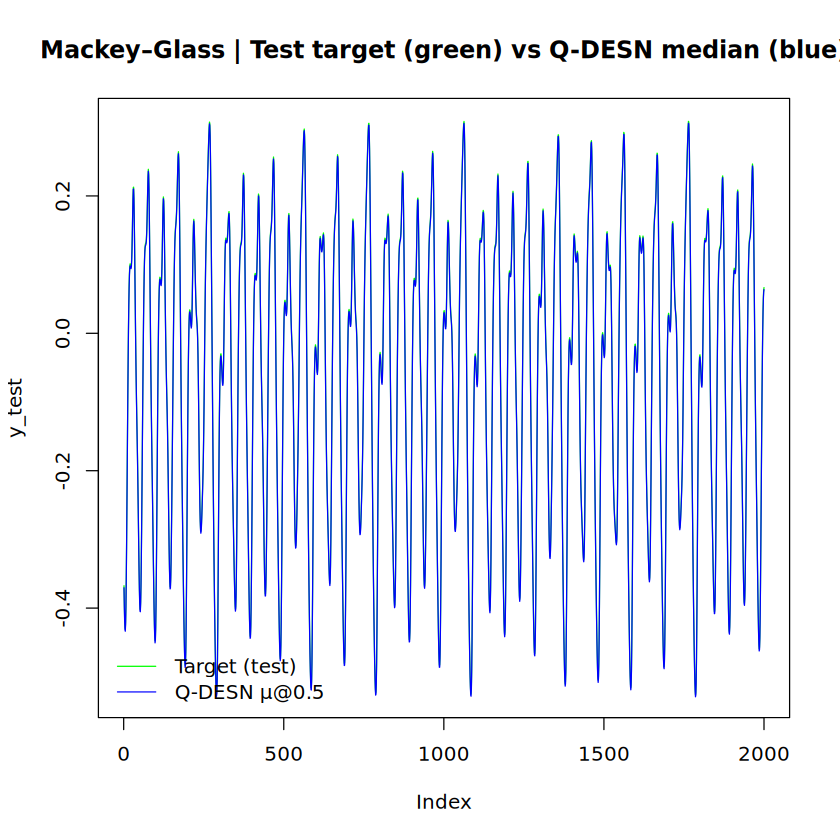

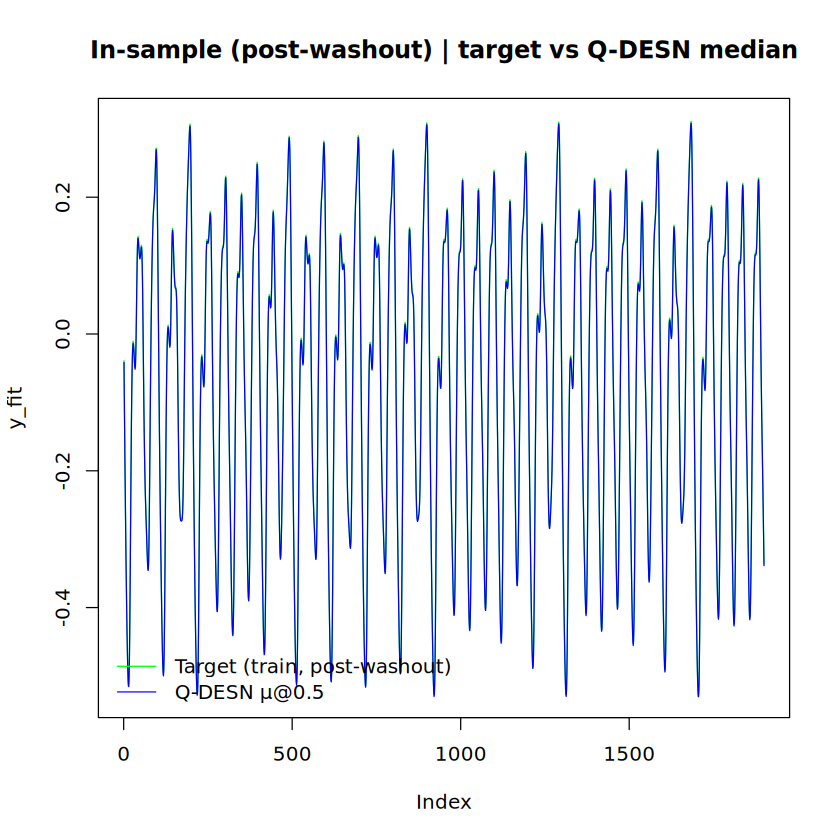

In [ ]:
# Q-DESN (p0 = 0.5) on Mackey–Glass (delay=17), Jupyter-friendly
# Assumes qdesn_fit_vb(), exal_static_LDVB(), etc. are available (e.g., library(exdqlm))

## =====================================================================
## 0) Setup
## =====================================================================
req_pkgs <- c("devtools","ggplot2","dplyr","tidyr","tibble","scales")
need <- setdiff(req_pkgs, rownames(installed.packages()))
if (length(need)) install.packages(need, dependencies = TRUE)
invisible(lapply(req_pkgs, require, character.only = TRUE))

# Load your local package so exdqlm:::qdesn_fit_vb(), posterior_predict.qdesn_fit(),
# and exdqlm_synthesize_from_draws() are available.
devtools::load_all("/home/antonio/code/exdqlm")

set.seed(42)

## -------------------------------
## 1) Data & split
## -------------------------------
trainLen <- 2000
testLen  <- 2000
washout  <- 100   # like initLen in the minimal ESN

y_all <- as.numeric(read.table(
  url("https://mantas.info/wp/wp-content/uploads/simple_esn/MackeyGlass_t17.txt")
)[,1])

stopifnot(length(y_all) >= trainLen + testLen + 1)
y_train <- y_all[1:trainLen]
y_test  <- y_all[(trainLen+1):(trainLen+testLen)]

# quick peek (optional)
plot(y_all[1:1000], type="l", main="A sample of the data")

## -------------------------------
## 2) Fit your Q-DESN on the TRAIN segment only
## -------------------------------
# "Minimal-ESN-like" settings
D        <- 1L
n        <- c(300L)
n_tilde  <- integer(0)
m        <- 1L
alpha    <- 0.3
rho      <- rep(0.9, D)
add_bias <- TRUE

# If you want dense Win like in the minimal ESN, set pi_in = 1.0
vb_args  <- list(max_iter = 1000, tol = 1e-4, n_samp_xi = 200,
                 verbose = TRUE, stream = FALSE)

fit <- qdesn_fit_vb(
  y = y_train,
  p0 = 0.5,
  D = D,
  n = n,
  n_tilde = n_tilde,
  m = m,
  alpha = alpha,
  rho = rho,
  act_f = "tanh",
  act_k = "identity",
  pi_w = 0.1, pi_in = 1.0,   # <- dense input weights (feel free to switch back to 0.1)
  washout = washout,
  add_bias = add_bias,
  seed = 42,
  vb_args = vb_args
)

cat(sprintf("\nTrain rows used: %d (after washout=%d, m=%d)\n",
            nrow(fit$X), washout, m))

## -------------------------------
## 3) In-sample performance (@ p=0.5)
## -------------------------------
pinball_loss <- function(y, q, p) {
  u <- y - q
  mean(u * (p - (u < 0)))
}

y_fit   <- fit$y_fit
mu_fit  <- fit$mu_hat
pbl_fit <- pinball_loss(y_fit, mu_fit, p = 0.5)
mse_fit <- mean((y_fit - mu_fit)^2)

cat(sprintf("In-sample: pinball@0.5 = %.6g | MSE = %.6g\n", pbl_fit, mse_fit))

## -------------------------------
## 4) Teacher-forcing predictions on TEST segment
##    (roll the reservoir forward from end of training)
## -------------------------------
# Use the fitted reservoir and last training states; drive with true y_test.

# reuse same activation lookup as your code
get_act <- function(a) {
  if (is.function(a)) return(a)
  switch(tolower(a),
         "tanh"     = base::tanh,
         "relu"     = function(x) pmax(0, x),
         "identity" = function(x) x,
         stop("Unknown activation: ", a))
}
f_act <- get_act(fit$reservoir$act_f)
k_act <- get_act(fit$reservoir$act_k)

# Build u_t with the SAME preprocessing used at training (with fallbacks)
make_u_test <- function(y_hist, m, meta, y_train_for_fallback = NULL) {
  if (m == 0L) return(c(1))
  lags <- if (m > 0L) tail(y_hist, m) else numeric(0)

  # standardization (fallback to training stats if meta didn't store them)
  if (isTRUE(meta$standardize_inputs) && m > 0L) {
    lc <- meta$lag_center; ls <- meta$lag_scale
    if ((is.null(lc) || is.null(ls)) && !is.null(y_train_for_fallback)) {
      lc <- mean(y_train_for_fallback, na.rm = TRUE)
      ls <- stats::sd(y_train_for_fallback, na.rm = TRUE); if (!is.finite(ls) || ls <= 1e-12) ls <- 1
    }
    if (!is.null(lc) && !is.null(ls)) {
      lags <- (lags - lc) / ls
    }
  }

  # per-lag scaling
  if (!is.null(meta$win_scale_lags)) {
    lags <- lags * as.numeric(meta$win_scale_lags)
  }

  # bound inputs if requested
  if (!is.null(meta$input_bound) && meta$input_bound == "tanh") {
    lags <- tanh(lags)
  }

  u <- c(1, lags)
  u[1] <- u[1] * meta$win_scale_bias
  if (length(u) > 1L) u[-1] <- u[-1] * meta$win_scale_global
  u
}

# pull pieces from the fit
D_        <- fit$reservoir$D
n_        <- fit$reservoir$n
W_        <- fit$reservoir$W
Win_      <- fit$reservoir$Win
Q_        <- fit$reservoir$Q
alpha_    <- fit$reservoir$alpha    # vector (length D_)
add_bias_ <- fit$meta$add_bias

# grab layer-wise last states from training
H_all_train <- fit$states$H_all
h_prev <- lapply(seq_len(D_), function(d) {
  H_all_train[[d]][nrow(H_all_train[[d]]), ]
})

# history buffer for lags: last m observations from training
y_hist <- tail(y_train, m)

# storage for test predictions
mu_test <- numeric(testLen)

for (t in seq_len(testLen)) {
  # teacher forcing: build u_t from history with SAME preprocessing
  u_t <- make_u_test(y_hist, m, fit$meta, y_train_for_fallback = y_train)

  # layer 1 (layer-indexed leak)
  pre1   <- W_[[1]]  %*% h_prev[[1]] + Win_[[1]] %*% u_t
  omega1 <- f_act(pre1)
  h1     <- (1 - alpha_[1]) * h_prev[[1]] + alpha_[1] * omega1
  h_prev[[1]] <- as.numeric(h1)

  # deeper layers if any (use alpha_[d])
  if (D_ >= 2L) {
    for (d in 2:D_) {
      htilde <- Q_[[d - 1]] %*% h_prev[[d - 1]]
      pred   <- W_[[d]] %*% h_prev[[d]] + Win_[[d]] %*% htilde
      omegad <- f_act(pred)
      hd     <- (1 - alpha_[d]) * h_prev[[d]] + alpha_[d] * omegad
      h_prev[[d]] <- as.numeric(hd)
    }
  }

  # build x_t = [ h_{t,D}; k(tilde h_{t,1}); ... ] (+ bias if used)
  x_low <- if (D_ == 1L) numeric(0) else {
    as.numeric(do.call(c, lapply(seq_len(D_ - 1L), function(d) k_act(Q_[[d]] %*% h_prev[[d]]))))
  }
  x_t <- c(h_prev[[D_]], x_low)
  if (add_bias_) x_t <- c(1, x_t)

  # linear readout
  beta_hat <- as.numeric(fit$fit$qbeta$m)
  mu_test[t] <- sum(x_t * beta_hat)

  # update y history (teacher forcing uses true next y)
  y_hist <- c(y_hist, y_test[t])
  if (length(y_hist) > m) y_hist <- tail(y_hist, m)
}

# Evaluate on test
pbl_test <- pinball_loss(y_test, mu_test, p = 0.5)
mse_test <- mean((y_test - mu_test)^2)
cat(sprintf("Test (teacher-forced): pinball@0.5 = %.6g | MSE = %.6g\n", pbl_test, mse_test))

# For direct comparison with the tutorial's 'early' error window:
errorLen <- 500
pbl_early <- pinball_loss(y_test[1:errorLen], mu_test[1:errorLen], p = 0.5)
mse_early <- mean((y_test[1:errorLen] - mu_test[1:errorLen])^2)
cat(sprintf("Test first %d steps: pinball@0.5 = %.6g | MSE = %.6g\n", errorLen, pbl_early, mse_early))


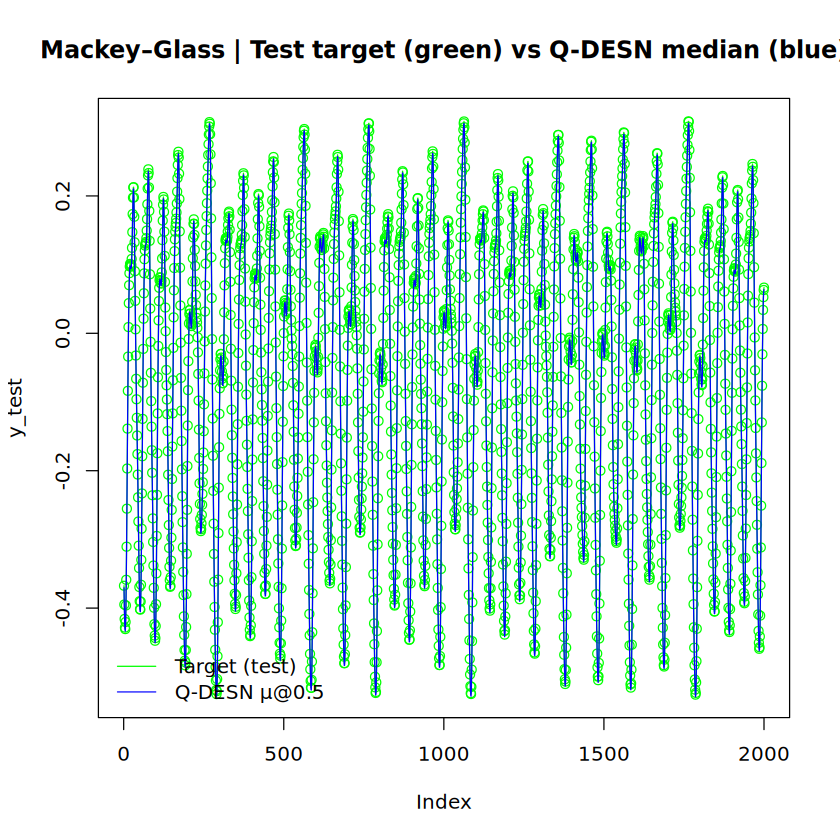

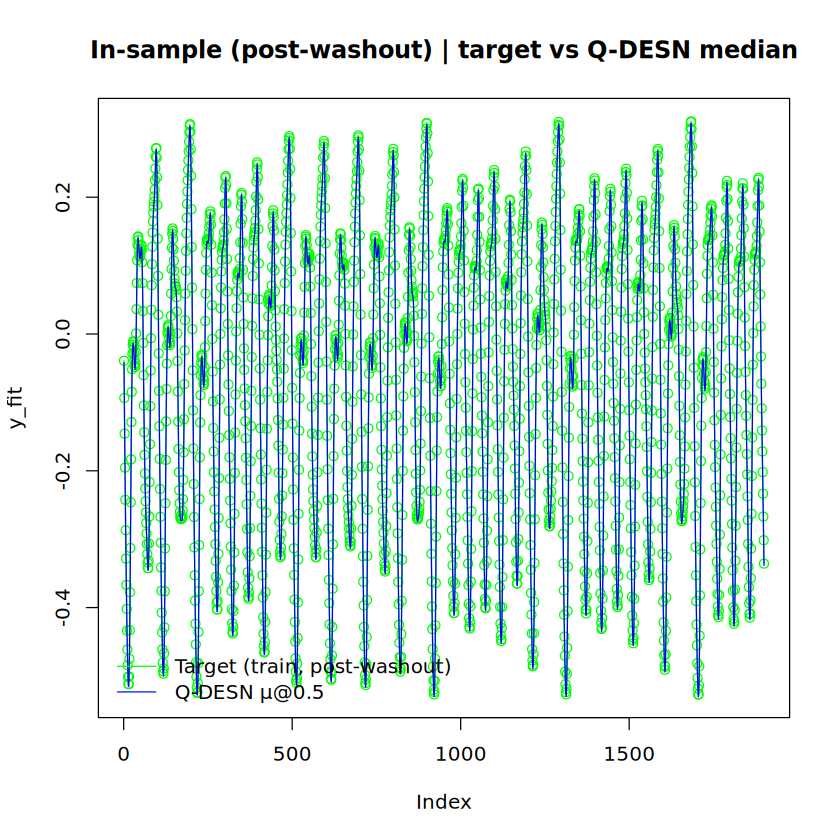

In [8]:

## -------------------------------
## 5) Plots
## -------------------------------
# Test: target vs Q-DESN median prediction (teacher forcing)
plot(y_test, type="o", col="green",
     main="Mackey–Glass | Test target (green) vs Q-DESN median (blue)")
lines(mu_test, col="blue")
legend("bottomleft", c("Target (test)", "Q-DESN μ@0.5"),
       col=c("green","blue"), lty=1, bty="n")

# In-sample trace (post-washout)
plot(y_fit, type="o", col="green",
     main="In-sample (post-washout) | target vs Q-DESN median")
lines(mu_fit, col="blue")
legend("bottomleft", c("Target (train, post-washout)", "Q-DESN μ@0.5"),
       col=c("green","blue"), lty=1, bty="n")
